# Determinants of Life Expectancy — Multiple Linear Regression

## Objective

Build a multiple linear regression model for **Life Expectancy** using health, demographic and economic indicators.

### Important design decision

The raw data contain repeated country observations from 2000–2015. The main regression is deliberately **cross-sectional**, using one year only. This avoids treating repeated observations from the same country as independent observations in an ordinary OLS model.

Therefore:

- missingness is checked **before** imputation;
- variables with excessive missingness are excluded

A cleaner year is selected for the final cross-sectional analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy.stats import jarque_bera
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

def calculate_vif(X):
    Xc = sm.add_constant(X)
    rows = []
    for i, col in enumerate(Xc.columns):
        if col != "const":
            rows.append({
                "Variable": col,
                "VIF": variance_inflation_factor(Xc.values, i)
            })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

def regression_metrics(y_true, pred):
    return {
        "R²": r2_score(y_true, pred),
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred))
    }


## 1. Load and clean the data

In [2]:
df = pd.read_csv("Life Expectancy Data.csv")
df.columns = df.columns.str.strip()
df = df.drop_duplicates().copy()

for col in df.columns:
    if col not in ["Country", "Status"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
print("Countries:", df["Country"].nunique())
print("Years:", sorted(df["Year"].unique()))
display(df.head())


Shape: (2938, 22)
Countries: 193
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 2. Missing-value audit by year

In [3]:
missing_by_year = []

for year in sorted(df["Year"].unique()):
    d = df[df["Year"] == year]
    numeric_cols = [c for c in d.columns if c not in ["Country", "Status", "Year"]]
    missing_by_year.append({
        "Year": year,
        "Observations": len(d),
        "Average % missing": 100 * d[numeric_cols].isna().mean().mean(),
        "Total expenditure missing": d["Total expenditure"].isna().sum(),
        "Alcohol missing": d["Alcohol"].isna().sum(),
        "Population missing": d["Population"].isna().sum(),
        "GDP missing": d["GDP"].isna().sum()
    })

year_missing = pd.DataFrame(missing_by_year)
display(year_missing.round(2))


,Year,Observations,Average % missing,Total expenditure missing,Alcohol missing,Population missing,GDP missing
0,2000,183,5.87,4,1,40,29
1,2001,183,5.55,4,1,40,28
2,2002,183,4.98,4,1,40,28
3,2003,183,4.43,3,1,40,28
4,2004,183,4.20,3,1,40,27
5,2005,183,3.97,3,2,40,27
6,2006,183,3.77,3,1,40,27
7,2007,183,3.54,3,1,40,27
8,2008,183,3.42,3,1,40,27
9,2009,183,3.34,3,1,40,27


## Selecting model year

In [4]:
MODEL_YEAR = 2010
data = df[df["Year"] == MODEL_YEAR].copy()

print("Selected year:", MODEL_YEAR)
print("Observations:", len(data))
display(data.isna().sum().sort_values(ascending=False).to_frame("Missing values"))


Selected year: 2010
Observations: 183


,Missing values
Population,40
GDP,27
Hepatitis B,15
Income composition of resources,10
Schooling,10
Total expenditure,3
thinness 1-19 years,2
thinness 5-9 years,2
BMI,2
Alcohol,1


## 4. Candidate predictors and redundancy

In [5]:
candidate_features = [
    "Status",
    "Adult Mortality",
    "infant deaths",
    "Alcohol",
    "percentage expenditure",
    "Hepatitis B",
    "Measles",
    "BMI",
    "under-five deaths",
    "Polio",
    "Total expenditure",
    "Diphtheria",
    "HIV/AIDS",
    "GDP",
    "Population",
    "thinness  1-19 years",
    "thinness 5-9 years",
    "Income composition of resources",
    "Schooling"
]

missing_pct = data[candidate_features].isna().mean().sort_values(ascending=False) * 100
display(missing_pct.to_frame("Missing %").round(2))


,Missing %
Population,21.86
GDP,14.75
Hepatitis B,8.20
Schooling,5.46
Income composition of resources,5.46
Total expenditure,1.64
BMI,1.09
thinness 1-19 years,1.09
thinness 5-9 years,1.09
Diphtheria,0.55


In [6]:
missing_threshold = 0.25

available_features = [
    c for c in candidate_features
    if data[c].isna().mean() <= missing_threshold
]

print("Retained after missingness screening:")
for c in available_features:
    print(" -", c)

print("\nExcluded for excessive missingness:")
for c in candidate_features:
    if c not in available_features:
        print(" -", c)


Retained after missingness screening:
 - Status
 - Adult Mortality
 - infant deaths
 - Alcohol
 - percentage expenditure
 - Hepatitis B
 - Measles
 - BMI
 - under-five deaths
 - Polio
 - Total expenditure
 - Diphtheria
 - HIV/AIDS
 - GDP
 - Population
 - thinness  1-19 years
 - thinness 5-9 years
 - Income composition of resources
 - Schooling

Excluded for excessive missingness:


## 5. Exploratory data analysis

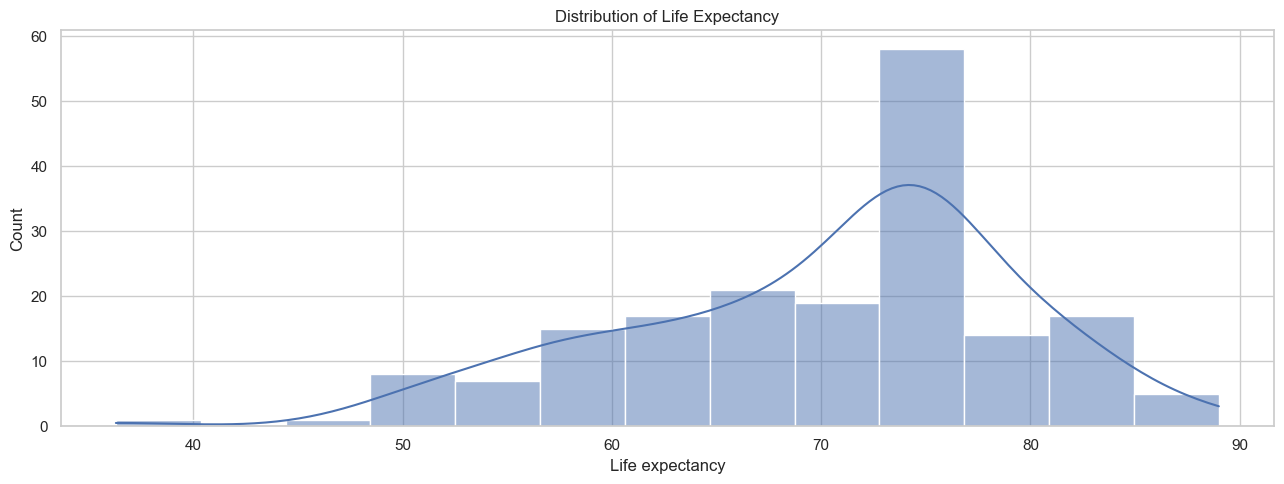

Life expectancy skewness: -0.6418639259589055


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

sns.histplot(data["Life expectancy"].dropna(), kde=True, ax=ax)

ax.set_title("Distribution of Life Expectancy")
ax.set_xlabel("Life expectancy")

plt.tight_layout()
plt.show()

print("Life expectancy skewness:", data["Life expectancy"].skew())

The distribution of life expectancy is moderately left-skewed (skewness = −0.64), with most observations concentrated between approximately 70 and 80 years. This provides an initial understanding of the response distribution and motivates evaluating alternative response transformations during model refinement.

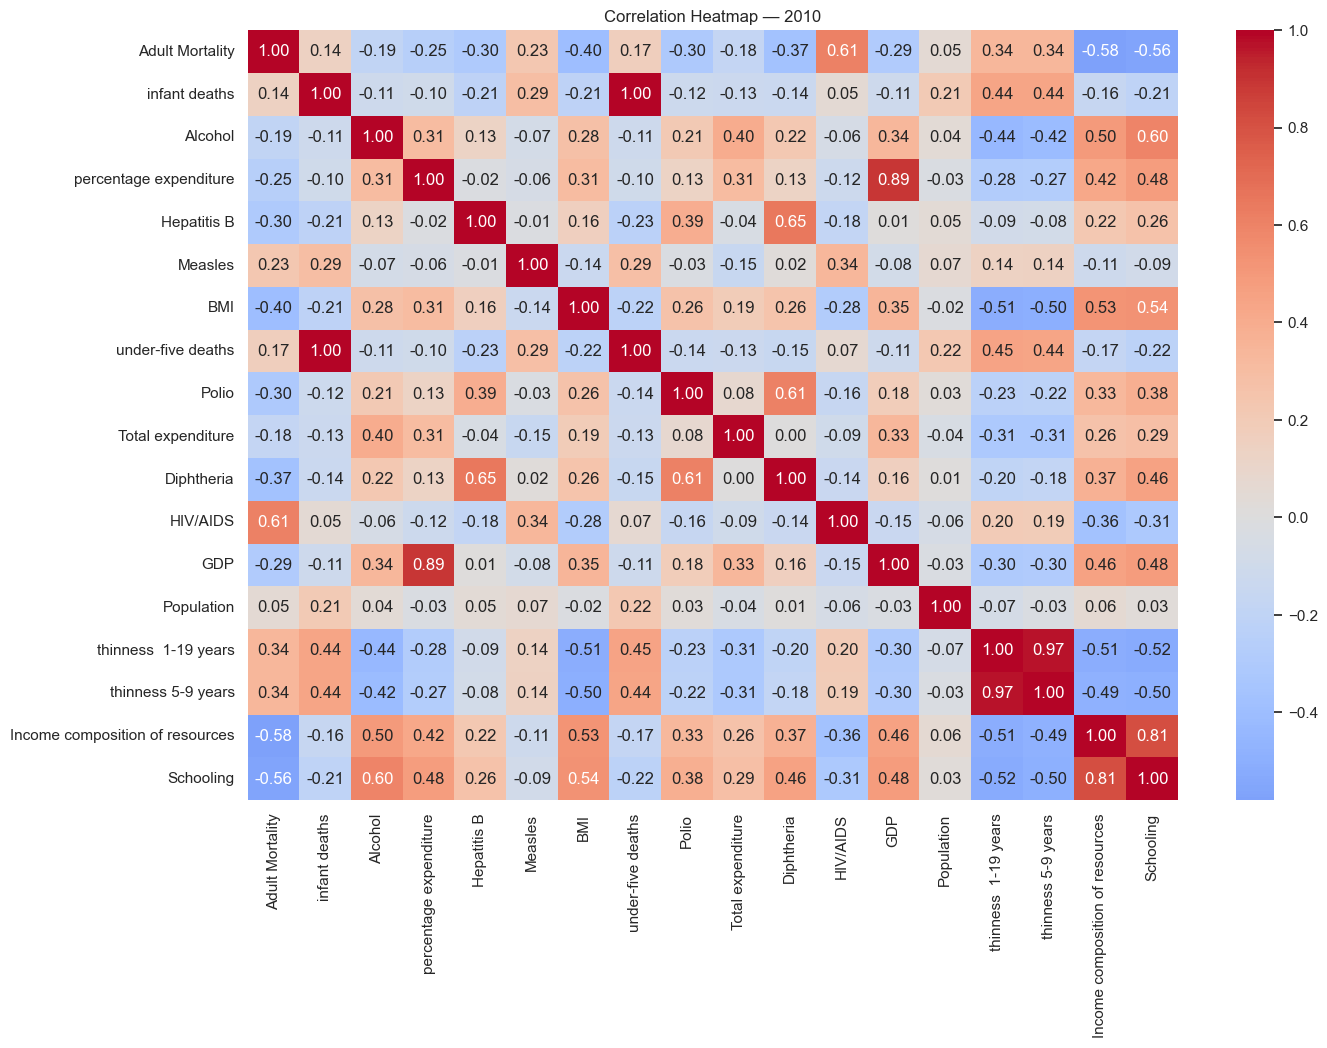

infant deaths vs under-five deaths: 0.9970049049286879
thinness 1-19 vs thinness 5-9: 0.9735115694329229


In [8]:
corr_cols = [c for c in available_features if c != "Status"]

plt.figure(figsize=(15, 10))
sns.heatmap(
    data[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap — 2010")
plt.show()

print("infant deaths vs under-five deaths:",
      data["infant deaths"].corr(data["under-five deaths"]))
print("thinness 1-19 vs thinness 5-9:",
      data["thinness  1-19 years"].corr(data["thinness 5-9 years"]))

Highly correlated predictor pairs are examined below along with their linear relationships with Life Expectancy, to assess their relevance to the response; and to determine which variable to retain and which to exclude.

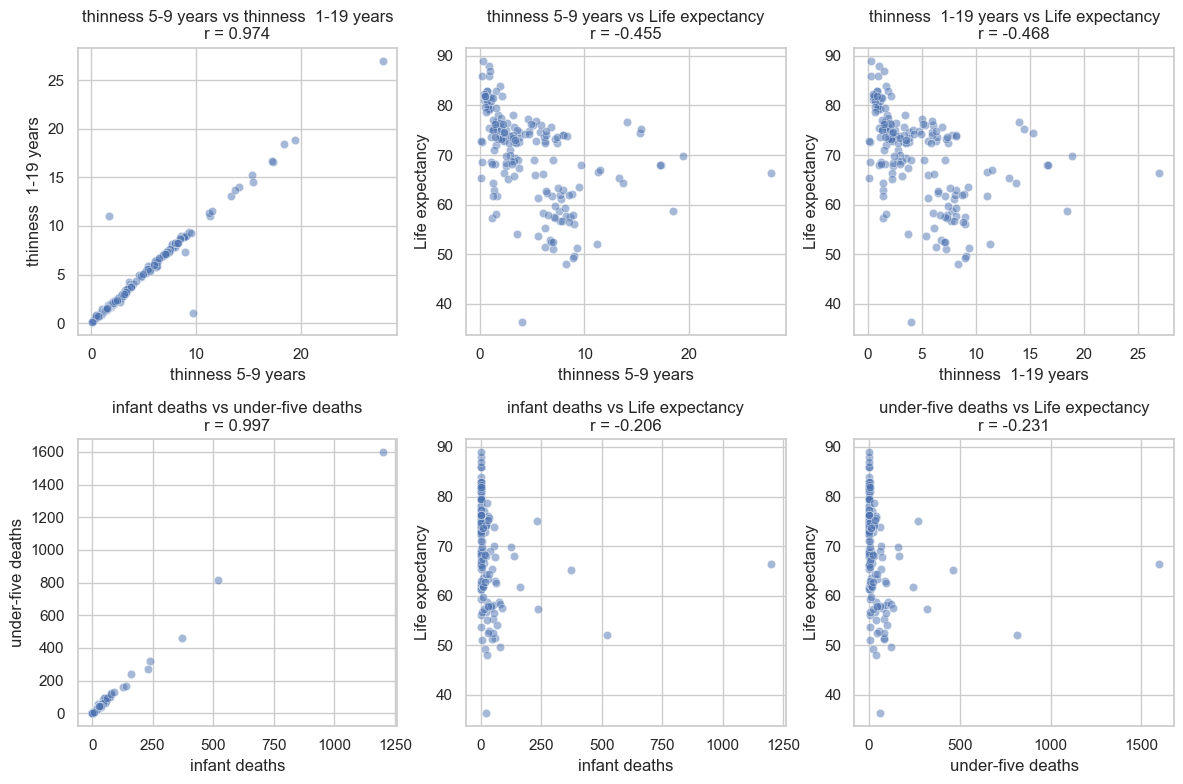

In [9]:
pairs = [
    ("thinness 5-9 years", "thinness  1-19 years"),
    ("infant deaths", "under-five deaths"),
]

fig, ax = plt.subplots(2, 3, figsize=(12, 8))

for i, (x1, x2) in enumerate(pairs):
    for j, (x, y) in enumerate([(x1, x2), (x1, "Life expectancy"), 
                                 (x2, "Life expectancy")]):
        d = data[[x, y]].dropna()
        r = d.corr().iloc[0, 1]
        sns.scatterplot(data=d, x=x, y=y, ax=ax[i,j], alpha=.5)
        ax[i,j].set_title(f"{x} vs {y}\nr = {r:.3f}")

plt.tight_layout()
plt.show()

## 6. Train-test split

In [10]:
analysis_data = data.dropna(subset=["Life expectancy"]).copy()

train_df_orig, test_df_orig = train_test_split(
    analysis_data,
    test_size=0.20,
    random_state=42,
    stratify=analysis_data["Status"]
)

print("Training observations:", len(train_df_orig))
print("Testing observations :", len(test_df_orig))


Training observations: 146
Testing observations : 37


In [11]:
vars_to_drop = ["thinness 5-9 years", "infant deaths"]

train_df = train_df_orig.drop(columns=vars_to_drop)
test_df = test_df_orig.drop(columns=vars_to_drop)

print("Dropped:", vars_to_drop)
print("Remaining columns:", list(train_df.columns))

Dropped: ['thinness 5-9 years', 'infant deaths']
Remaining columns: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'Income composition of resources', 'Schooling']


## 7. Missing-value treatment

Missingness is assessed on the training sample before imputation.

- variables with more than 25% missingness are excluded;
- remaining numeric predictors are median-imputed;
- medians are learned **only from the training data**;
- those same medians are applied to the test data.

In [12]:
available_features = [x for x in available_features
                  if x not in vars_to_drop]

model_features = [
    c for c in available_features
    if train_df[c].replace([np.inf, -np.inf], np.nan).isna().mean() <= missing_threshold
]

numeric_features = [c for c in model_features if c != "Status"]

train_num = train_df[numeric_features].replace([np.inf, -np.inf], np.nan)
test_num = test_df[numeric_features].replace([np.inf, -np.inf], np.nan)

train_medians = train_num.median()

X_train = train_num.fillna(train_medians)
X_test = test_num.fillna(train_medians)

print("Remaining missing values - train:", X_train.isna().sum().sum())
print("Remaining missing values - test :", X_test.isna().sum().sum())

Remaining missing values - train: 0
Remaining missing values - test : 0


## 8. Outlier screening


Extreme values are not automatically removed because they may represent genuine country-level differences. Instead, potential outliers and influential observations are assessed after fitting the regression model using R-student residuals, leverage and Cook's distance.

## 9. Predictor skewness and transformations

In [13]:
skewness = X_train.skew().sort_values(
    key=lambda s: s.abs(),
    ascending=False
)
display(skewness.to_frame("Skewness"))

,Skewness
Measles,9.684699
under-five deaths,5.901518
Population,4.684694
percentage expenditure,4.557446
HIV/AIDS,3.877696
GDP,3.489291
Polio,-2.345604
Hepatitis B,-2.103031
Diphtheria,-2.030153
thinness 1-19 years,1.416620


In [14]:
log_candidates = [
    c for c in [
        "infant deaths",
        "percentage expenditure",
        "Measles",
        "HIV/AIDS",
        "GDP",
        "Population",
        "thinness  1-19 years"
    ]
    if c in X_train.columns and X_train[c].skew() > 1
]

print("Log-transformation candidates:")
for c in log_candidates:
    print(" -", c)

X_train_trans = X_train.copy()
X_test_trans = X_test.copy()

for c in log_candidates:
    X_train_trans[c] = np.log1p(X_train_trans[c].clip(lower=0))
    X_test_trans[c] = np.log1p(X_test_trans[c].clip(lower=0))

display(pd.DataFrame({
    "Original skewness": X_train[log_candidates].skew(),
    "Transformed skewness": X_train_trans[log_candidates].skew()
}).round(3))


Log-transformation candidates:
 - percentage expenditure
 - Measles
 - HIV/AIDS
 - GDP
 - Population
 - thinness  1-19 years


,Original skewness,Transformed skewness
percentage expenditure,4.557,-0.361
Measles,9.685,0.441
HIV/AIDS,3.878,2.003
GDP,3.489,-0.388
Population,4.685,-0.535
thinness 1-19 years,1.417,0.155


## 10. Baseline OLS with transformed predictors

In [15]:
X_train_ols = X_train_trans.copy()
X_train_ols["Status_Developed"] = (
    train_df["Status"] == "Developed"
).astype(int)

X_train_ols = sm.add_constant(X_train_ols.astype(float))
y_train = train_df["Life expectancy"].astype(float)

ols_baseline = sm.OLS(y_train, X_train_ols).fit()
print(ols_baseline.summary())


                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     52.23
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           3.96e-49
Time:                        10:46:03   Log-Likelihood:                -381.23
No. Observations:                 146   AIC:                             798.5
Df Residuals:                     128   BIC:                             852.2
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [16]:
baseline_resid = ols_baseline.resid

bp_baseline = het_breuschpagan(
    baseline_resid,
    ols_baseline.model.exog
)
jb_baseline = jarque_bera(baseline_resid)

baseline_diagnostics = pd.Series({
    "Adjusted R²": ols_baseline.rsquared_adj,
    "Maximum VIF": calculate_vif(
        X_train_ols.drop(columns="const")
    )["VIF"].max(),
    "Breusch-Pagan p-value": bp_baseline[1],
    "Jarque-Bera p-value": jb_baseline[1],
    "Durbin-Watson": durbin_watson(baseline_resid)
})

display(baseline_diagnostics)


Adjusted R²              0.857274
Maximum VIF              3.950877
Breusch-Pagan p-value    0.549948
Jarque-Bera p-value      0.000031
Durbin-Watson            1.965559
dtype: float64

The diagnostic tests indicate that multicollinearity and heteroscedasticity are not major concerns, with a maximum VIF of 3.95 and a Breusch–Pagan p-value of 0.550. However, the Jarque–Bera test is significant (p < 0.001), indicating that the residuals deviate from normality. Therefore, response transformations are evaluated primarily to improve the residual distribution and overall model diagnostics.

## 11. Response transformation

Life expectancy is strictly positive, so a log transformation is possible. We compare:

1. original response;
2. log response;
3. Yeo–Johnson response.

The transformation is kept only if it materially improves the residual diagnostics.


In [17]:
# Log response
y_log = np.log(y_train.to_numpy())
ols_log = sm.OLS(y_log, X_train_ols).fit()

# Yeo-Johnson response
y_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

y_yj = y_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

ols_yj = sm.OLS(y_yj, X_train_ols).fit()

def diagnostic_summary(model):
    r = model.resid
    bp = het_breuschpagan(r, model.model.exog)
    jb = jarque_bera(r)

    return {
        "Adjusted R²": model.rsquared_adj,
        "Breusch-Pagan p": bp[1],
        "Jarque-Bera p": jb[1],
        "Durbin-Watson": durbin_watson(r)
    }

response_comparison = pd.DataFrame({
    "Original": diagnostic_summary(ols_baseline),
    "Log": diagnostic_summary(ols_log),
    "Yeo-Johnson": diagnostic_summary(ols_yj)
}).T

display(response_comparison.round(4))
print("Yeo-Johnson lambda:", y_transformer.lambdas_[0])


,Adjusted R²,Breusch-Pagan p,Jarque-Bera p,Durbin-Watson
Original,0.8573,0.5499,0.0000,1.9656
Log,0.8383,0.1231,0.0000,2.0727
Yeo-Johnson,0.8531,0.4593,0.7389,1.8391


Yeo-Johnson lambda: 2.919323290132987


### Decision

The Yeo–Johnson transformation is retained because it substantially improves residual normality while maintaining a high adjusted \(R^2\) and showing no evidence of heteroscedasticity.

## 12. Refined OLS

In [18]:
final_ols = ols_yj
final_resid = final_ols.resid

print(final_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     50.52
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.47e-48
Time:                        10:46:03   Log-Likelihood:                -1568.3
No. Observations:                 146   AIC:                             3173.
Df Residuals:                     128   BIC:                             3226.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## 13. Multicollinearity — final VIF

In [19]:
final_vif = calculate_vif(
    X_train_ols.drop(columns="const")
)

display(final_vif)
print("Maximum VIF:", final_vif["VIF"].max())

,Variable,VIF
15,Schooling,3.950877
14,Income composition of resources,3.029946
9,Diphtheria,2.741155
1,Alcohol,2.325057
11,GDP,2.319832
16,Status_Developed,2.260486
0,Adult Mortality,2.255327
3,Hepatitis B,2.209159
13,thinness 1-19 years,2.185579
10,HIV/AIDS,2.184306


Maximum VIF: 3.9508774725651583


## 14. Final OLS assumption checks

In [20]:
bp_final = het_breuschpagan(
    final_resid,
    final_ols.model.exog
)
jb_final = jarque_bera(final_resid)

final_diagnostics = pd.Series({
    "Adjusted R²": final_ols.rsquared_adj,
    "Maximum VIF": final_vif["VIF"].max(),
    "Breusch-Pagan p-value": bp_final[1],
    "Jarque-Bera p-value": jb_final[1],
    "Durbin-Watson": durbin_watson(final_resid)
})

display(final_diagnostics)


Adjusted R²              0.853057
Maximum VIF              3.950877
Breusch-Pagan p-value    0.459298
Jarque-Bera p-value      0.738871
Durbin-Watson            1.839094
dtype: float64

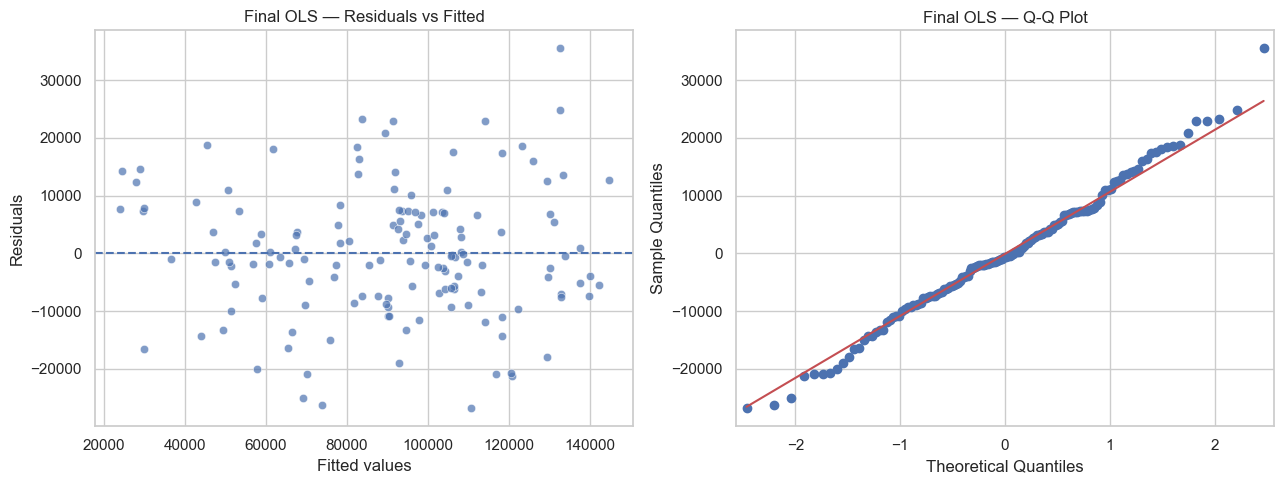

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    x=final_ols.fittedvalues,
    y=final_resid,
    alpha=0.7,
    ax=axes[0]
)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Final OLS — Residuals vs Fitted")

sm.qqplot(final_resid, line="q", ax=axes[1])
axes[1].set_title("Final OLS — Q-Q Plot")

plt.tight_layout()
plt.show()


Diagnostic plots provide visual support for the formal assumption tests. 
- The Residuals vs Fitted plot shows the residuals scattered around zero without a clear funnel-shaped pattern, supporting the Breusch–Pagan test result that provides no evidence of heteroscedasticity. 
- The Q–Q plot shows that most residuals lie reasonably close to the reference line, with some deviations in the tails. This is broadly consistent with the Jarque–Bera test, which provides no statistical evidence against the normality of residuals.

## 15. Influential observations

Influence is checked **after** missing-value treatment and transformations.

We use:
- leverage;
- R-student;
- Cook's distance.

In [22]:
influence = final_ols.get_influence()
influence_df = influence.summary_frame()

influence_table = pd.DataFrame({
    "R-student": influence_df["student_resid"],
    "leverage": influence_df["hat_diag"],
    "cooks_distance": influence_df["cooks_d"]
}, index=train_df.index)

display(
    influence_table[influence_table["R-student"].abs() > 3]
)


,R-student,leverage,cooks_distance
1834,3.295474,0.125401,0.08032


|R-student|>3 flagged observation 1834 as a potential outlier. Its leverage and Cook’s distance were subsequently examined to assess its unusual predictor values and influence on the fitted model. Although the observation was flagged as an outlier, it did not exhibit particularly high leverage or strong influence. Therefore, it was retained.

## 16. Ridge, Lasso and Elastic Net

In [23]:
X_train_reg = X_train_trans.copy()
X_test_reg = X_test_trans.copy()

X_train_reg["Status_Developed"] = (
    train_df["Status"] == "Developed"
).astype(int)

X_test_reg["Status_Developed"] = (
    test_df["Status"] == "Developed"
).astype(int)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

reg_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

regularized_models = {
    "Ridge": (
        Ridge(),
        {"model__alpha": np.logspace(-4, 4, 40)}
    ),
    "Lasso": (
        Lasso(max_iter=50000),
        {"model__alpha": np.logspace(-4, 0, 40)}
    ),
    "Elastic Net": (
        ElasticNet(max_iter=50000),
        {
            "model__alpha": np.logspace(-4, 0, 25),
            "model__l1_ratio": np.linspace(0.05, 0.95, 10)
        }
    )
}

regularized_results = {}

for name, (estimator, params) in regularized_models.items():
    pipe = Pipeline([
        ("preprocess", reg_preprocess),
        ("model", estimator)
    ])

    grid = GridSearchCV(
        pipe,
        params,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(X_train_reg, y_yj)
    regularized_results[name] = grid

    print(name, "best parameters:", grid.best_params_)


Ridge best parameters: {'model__alpha': np.float64(21.54434690031882)}
Lasso best parameters: {'model__alpha': np.float64(1.0)}
Elastic Net best parameters: {'model__alpha': np.float64(0.21544346900318823), 'model__l1_ratio': np.float64(0.05)}


In [24]:
results_train = []
n = len(y_train)
p = X_train_reg.shape[1]

# Refined OLS
pred_yj = final_ols.predict(X_train_ols)
pred_ols_train = y_transformer.inverse_transform(
    np.asarray(pred_yj).reshape(-1, 1)
).ravel()

r = regression_metrics(y_train, pred_ols_train)
r["Model"] = "Refined OLS"
r["Adj R²"] = 1 - (1 - r["R²"]) * (n - 1) / (n - p - 1)
results_train.append(r)

# Ridge, Lasso, Elastic Net
for name, grid in regularized_results.items():
    pred_yj = grid.predict(X_train_reg)
    pred_original = y_transformer.inverse_transform(
        np.asarray(pred_yj).reshape(-1, 1)
    ).ravel()

    r = regression_metrics(y_train, pred_original)
    r["Model"] = name
    r["Adj R²"] = 1 - (1 - r["R²"]) * (n - 1) / (n - p - 1)
    results_train.append(r)

train_results = pd.DataFrame(results_train)[
    ["Model", "R²", "Adj R²", "MAE", "RMSE"]
]

display(train_results.sort_values("RMSE"))

,Model,R²,Adj R²,MAE,RMSE
0,Refined OLS,0.861125,0.842681,2.588122,3.458688
2,Lasso,0.861124,0.842679,2.588029,3.458711
1,Ridge,0.858889,0.840148,2.568689,3.486423
3,Elastic Net,0.856448,0.837383,2.574999,3.516450


## 17. Cross-Country Out-of-Sample Evaluation for 2010

In [25]:
X_test_ols = X_test_trans.copy()
X_test_ols["Status_Developed"] = (
    test_df["Status"] == "Developed"
).astype(int)

X_test_ols = sm.add_constant(
    X_test_ols.astype(float),
    has_constant="add"
)

y_test = test_df["Life expectancy"].astype(float).to_numpy()

pred_yj_ols = final_ols.predict(X_test_ols)

pred_ols = y_transformer.inverse_transform(
    np.asarray(pred_yj_ols).reshape(-1, 1)
).ravel()

results = []

r = regression_metrics(y_test, pred_ols)
r["Model"] = "Refined OLS"
results.append(r)

for name, grid in regularized_results.items():
    pred_yj = grid.predict(X_test_reg)

    pred_original = y_transformer.inverse_transform(
        np.asarray(pred_yj).reshape(-1, 1)
    ).ravel()

    r = regression_metrics(y_test, pred_original)
    r["Model"] = name
    results.append(r)

final_results = pd.DataFrame(results)[
    ["Model", "R²", "MAE", "RMSE"]
].sort_values("RMSE")

display(final_results)


,Model,R²,MAE,RMSE
1,Ridge,0.722573,3.698120,4.856527
3,Elastic Net,0.722052,3.709503,4.861088
2,Lasso,0.715826,3.771389,4.915228
0,Refined OLS,0.715804,3.771652,4.915416


# Conclusion

This project developed a regression-based framework for predicting life expectancy across 193 countries using demographic, health, economic and social indicators. Through systematic data cleaning, missing-value treatment, variable selection, outlier and influence assessment, transformation and diagnostic evaluation, the regression model was progressively refined.

The refined OLS model was subsequently compared with Ridge, Lasso and Elastic Net on unseen test data. All four models demonstrated similar predictive performance. Although Ridge showed a small numerical advantage, the differences between the models were modest.